# ```Ollama``` Tutorial #

### Instalation ###
First we need to download ([link](https://ollama.com/download)) and install ```Ollama``` (models are stored at ```C:\Users\[USER_NAME]\.ollama\models```).

For the Python client, ```ollama-python``` can be installed via ```pip3 install ollama-python```.

### Documentation ###
- ```Ollama``` Documentation - [Link](https://docs.ollama.com/quickstart);
- ```ollama-python``` Git Repo (Examples) - [Link](https://github.com/ollama/ollama-python/tree/main/examples);
- FreeCodeCamp Customize LLMs Locally with ```Ollama``` - [Link](https://www.freecodecamp.org/news/run-and-customize-llms-locally-with-ollama/);

### Importing Dependencies ###

In [37]:
import json
import asyncio
import requests

from ollama import chat, AsyncClient, generate, ListResponse, list, ShowResponse, show

from IPython.display import Image

### What are Local LLMs? ###
Local Large Language Models (```LLMs```) bring AI off the cloud and onto personal hardware. While standard models are originally too large for consumers, a process called ```quantization``` (compression technique that reduces the numerical precision of a model's weights and activations) allows them to run locally without the need of massive servers.

### Why Run LLMs Locally? ###
Running an ```LLM``` locally is a strategic move for anyone who wants full control over their AI. Core benefits include:
- *Offline Usage*: not limited to the cloud (can explore the data without internet connection);
- *Privacy and Data Ownership*: since there's no cloud connection there is no risk of data/prompts exploitation by 3rd-parties;
- *Cost Control*: no subscriptions and tokens (essentially free);
- *Customization & Experimentation*: possibility to swap between multiple models instantly;
- *Faster Iteration for Dev Workflows*: local hosting eliminates network latency, allowing for near-instant responses;

The main tradeoff is that local models require memory (a small quantized model may be comfortable on a laptop, however larger models can require tenths of GBs of RAM) and enough free disk space for model files.

**Model Size and Quantization**<br>
A model's parameter count is not its complete memory requirement. At full 32-bit precision, 1B parameters needs ~4GB just for weights (a 7B model, ~28 GB before any runtime memory). This exceeds the capacity of many personal computers. ```Quantization``` *reduces the numerical precision used to represent weights*, allowing models to run with average RAM/GPUs.

```Quantization``` is a quality-resource trade-off. Common labels include ```Q4```, ```Q5```, ```Q6```, and ```Q8```. Lower values generally reduce RAM/disk use while introducing more approximation. Higher precision may improve output quality but requires more memory and can be slower.

Model inference also requires memory for the ```context window```, and we should always treat weights and context as separate capacity requirements.

### What is ```Ollama```? ###
```Ollama``` is a free, open-source tool that makes it easier to run LLMs locally. Before ```Ollama```, running a local AI demanded hunting for the right "weights" files, setting up complex coding environments, and hoping the hardware doesn't crash. Now, instead of spending hours configuring software, it handles the heavy lifting (automatically finds the GPU and tunes its settings).

**Mental Model**<br>
- *Model Registry*: maintains a massive ```Library``` (central library of prepackaged models) so there's no need to worry about file formats (just pick a model and ```Ollama``` pulls it to local);
- *The Local Runtime*: once we have a model, ```Ollama``` acts as the ```Engine```, waking up the model, loading it into memory, and starting the "thinking" process;
- *The CLI*: uses ```CLI``` to allow user to simply type human-like instructions into a terminal window;

**Request Lifecycle**<br>
A ```chat``` (```CLI```) request reaches the HTTP server, which resolves the requested model and ensures it is loaded. The text is formatted according to the model's ```chat``` template and tokenized. The inference engine produces output tokens one by one (if streaming is enabled, ```Ollama``` returns newline-delimited JSON objects as tokens become available). 

The first request after starting a model may be slower because it includes loading time. Subsequent requests are typically faster while the model remains in memory.

**API Reference**<br>
We can use ```Ollama```’s API to run and interact (via local HTTP calls) with models. The API is served by default at ```http://localhost:11434/api```. Once ```Ollama``` is running, its API is automatically available and can be accessed via ```curl``` (in this tutorial we'll use ```requests``` equivalent calls).

**Authentication**<br>
No authentication is required when accessing ```Ollama```’s API locally via ```http://localhost:11434```. Authentication is only required when:
- Running cloud models via ```ollama.com```;
- Publishing models;
- Downloading private models;

Two authentication methods are supported:
- *Signing in*: sign in from local installation (```ollama signin```) will automatically take care of authenticating requests to ```ollama.com``` when running commands;
- *API keys*: for programmatic access to ```ollama.com```’s API;

**API Keys**<br>
For direct access to ```ollama.com```’s API, authentication (via keys) is required. Keys can be created [here](https://ollama.com/settings/keys) and injected in calls via ```Authorization: Bearer``` header. Currently, API keys don’t currently expire, however can be revoked at any time (in Settings).

**Usage**<br>
```Ollama```’s API responses include metrics that can be used for tracking performance/model usage:
- ```total_duration```: how long response took to generate (in ns);
- ```load_duration```: how long model took to load (in ns);
- ```prompt_eval_count```: how many input tokens were processed;
- ```prompt_eval_duration```: how long it took to evaluate the prompt (in ns);
- ```eval_count```: how many output tokens were processed;
- ```eval_duration```: how long it took to generate the output tokens (in ns);

**Errors (Status Codes)**<br>
Endpoints return appropriate HTTP status codes based on requests' success/failure:
- ```200```: Success;
- ```400```: Bad Request (missing parameters, invalid JSON, etc);
- ```404```: Not Found (model doesn’t exist, etc);
- ```429```: Too Many Requests (ie rate limit is exceeded);
- ```500```: Internal Server Error;
- ```502```: Bad Gateway (ie cloud model cannot be reached);


### Interactive ```Chat``` (```CLI```) ###
Once installed, open ```Terminal``` and run ```ollama``` to open the interactive menu. From the menu we can:
- *Run a model*: start an interactive ```chat```;
- *Launch tools*: such as Claude Code, OpenClaw, VS Code, etc;

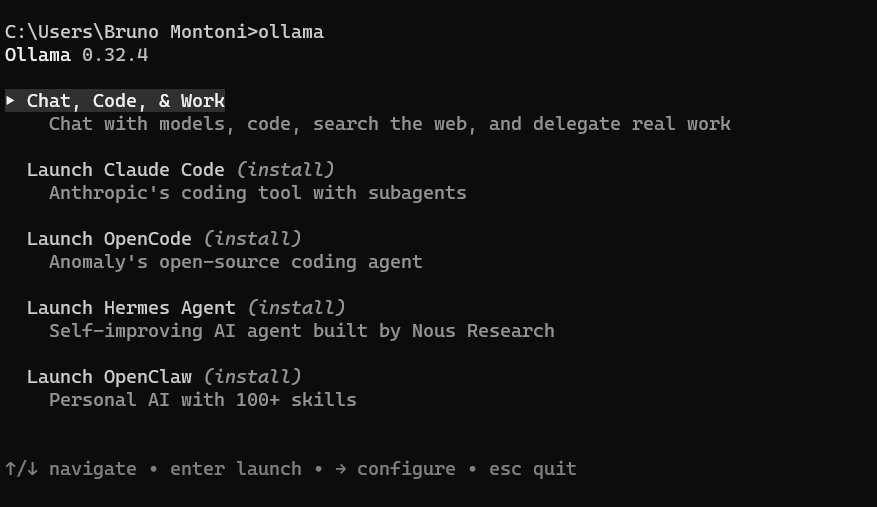

In [3]:
# Ollama Chat
Image(filename= "./img/ollama_chat.png", width= 600) 

**Running a Model**<br>
Running the ```ollama run [MODEL_NAME]``` downloads (if not already present) and launches an interactive terminal session for the chosen LLM model. It checks the local storage, fetches the quantized model weights, loads them into the local memory (RAM), and opens a prompt where you can chat or input images directly.

**Best Overall Tiny Models (Under 2B Parameters)**<br>
- ```Qwen2.5-0.5B```: extremely lightweight, highly accurate for its tiny size, and excellent for code or basic logic validation;
- ```Llama-3.2-1B```: highly optimized by Meta, great at following precise formatting instructions (JSON output), and highly responsive
- ```Gemma2-2B```: Google's lightweight option, slightly larger but offers excellent text generation quality for testing;

In this tutorial, we'll use ```Gemma2-2B``` (```ollama run gemma2:2b```) and chat with it via CLI.

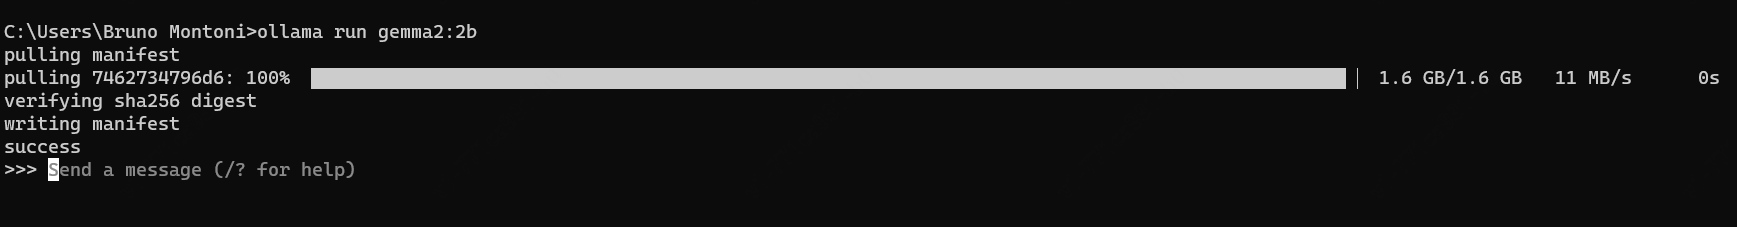

In [4]:
# Installing and loading a model
Image(filename= "./img/ollama_model.png", width= 800) 

Once the model is installed we can interact with it by sending messages (below):

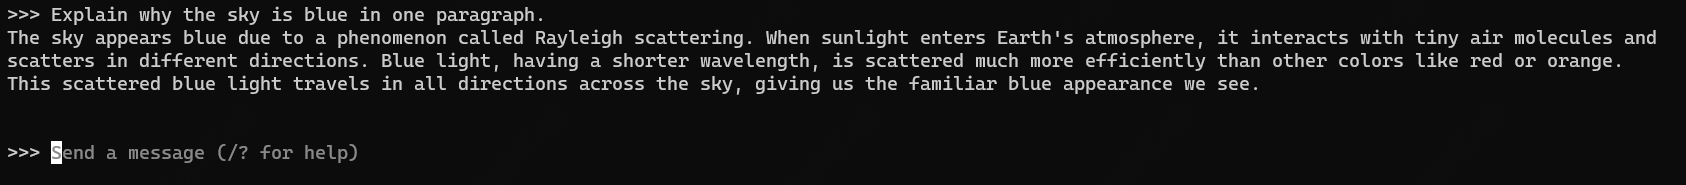

In [5]:
# Interacting with the model
Image(filename= "./img/ollama_model_output.png", width= 800) 

We can also list the downloaded models via ```ollama list```. Finally, we can run ```/bye``` to end the session.

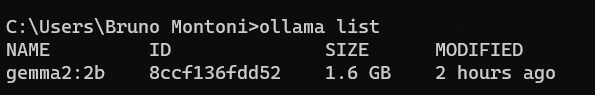

In [6]:
# Listing downloaded models
Image(filename= "./img/ollama_downloaded_models.png", width= 350) 

The full list of commands can be explored via ```ollama help```.

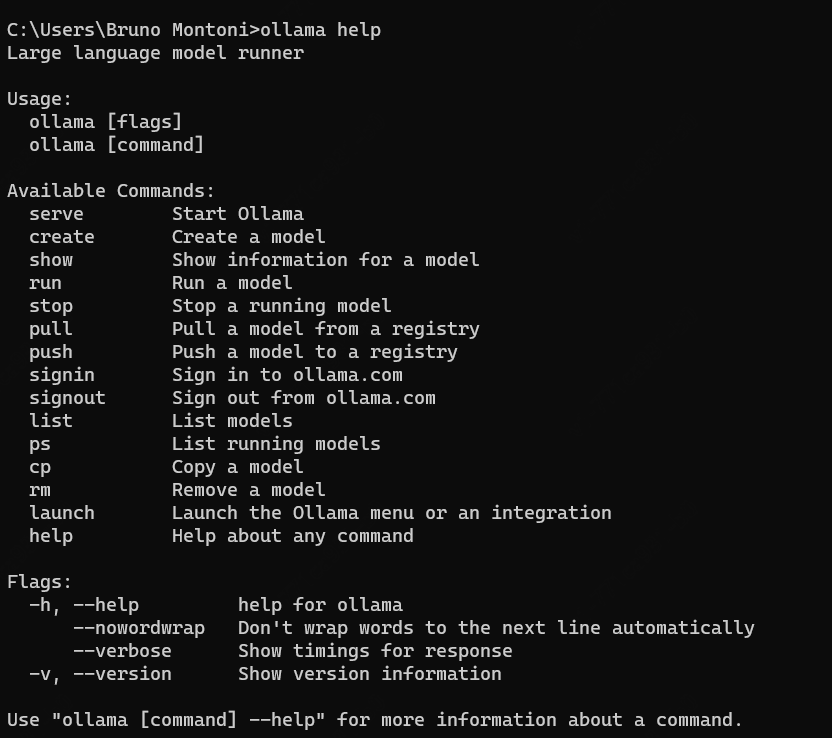

In [7]:
# Listing all Ollama commands
Image(filename= "./img/ollama_commands.png", width= 400) 

**Customize Local LLMs with Modelfiles**<br>
One of ```Ollama```’s most powerful features is the ability to customize a local model using ```Modelfiles```. ```Modelfiles``` allow you to *derive a model from a base model* (establish system instructions, generation defaults, message templates, and advanced cases—adapters), without any retraining or fine-tuning. This makes ```Modelfiles``` ideal for creating reusable, custom, task-specific local models (such as technical writers, code reviewers, research assistants, etc).

```Modelfiles``` and ```SKILL.md``` files are different concepts, though both are used to customize AI behavior. A ```Modelfile``` is a configuration blueprint used to create/package/start a custom local model (how base model should be wrapped, prompted, configured at runtime - it doesnt modify the underlying weights) starting from a base version; while an AI ```skill``` is a modular, plain-text ```markdown``` document that teaches an agent specific domain knowledge or workflows on demand.

**Modelfile Syntax and Structure**<br>
- ```FROM```: selects the base model;
- ```SYSTEM```: provides persistent behavioral instructions;
- ```PARAMETER```: controls generation behavior;
- ```TEMPLATE```: controls how messages are formatted before the model receives them (avoid changing it unless you understand the target model's expected prompt format; mismatches can significantly degrade quality.);

A low ```temperature``` generally makes output more stable and conservative; higher values introduce more variation (which can help creativity but make testing less reproducible). ```num_ctx``` controls the maximum context capacity and contributes to memory usage. ```repeat_penalty``` can reduce repetitive outputs.

### Local Model (REST) ###
Let's make an HTTP call to the model and instruct it to stream the response:

In [17]:
def stream_chat(model: str, prompt: str) -> None:
    payload = {"model": model,
               "stream": True,
               "messages": [{"role": "user", "content": prompt}]}

    with requests.post("http://localhost:11434/api/chat",
                       json= payload,
                       stream= True,
                       timeout= 120) as response:
        # 
        response.raise_for_status()
        # 
        for line in response.iter_lines(decode_unicode= True):
            if not line:
                continue
            event = json.loads(line)
            print(event.get("message", {}).get("content", ""), end= "", flush= True)
            if event.get("done"):
                print()
                break

In [18]:
# Calling 'stream_chat'
stream_chat(model= "gemma2:2b", prompt= "A brief explanation on why the sky is blue")

The blue color of the sky is due to a phenomenon called **Rayleigh scattering**. Here's a breakdown:

1. **Sunlight and Colors:** Sunlight is made up of all colors of the rainbow (visible spectrum).  Each color has its own wavelength.
2. **Earth's Atmosphere:** Earth's atmosphere is filled with tiny particles like nitrogen and oxygen molecules. These molecules are much smaller than the wavelengths of visible light. 
3. **Scattering of Light:** When sunlight enters the atmosphere, these particles scatter the light in different directions.  
4. **Blue Dominates:** Blue light has a shorter wavelength than other colors (like red or orange). It gets scattered more effectively by the atmospheric molecules because it's interacting with those tiny particles at a greater frequency and intensity. 
5. **The Sky Appears Blue:** This scattered blue light reaches our eyes from all directions across the sky, which is why we see the sky as blue.

**In short:** The sky appears blue because sunlight get


### Local Model (Client) ###
**Chat**: multi-turn, structured conversations;

In [26]:
# Building the message
messages = [{"role": "user", "content": "A brief explanation on why the sky is blue"}]
# Sending
response = chat(model= "gemma2:2b", messages= messages, stream= False) # 'stream': True for streaming 
print(response["message"]["content"])

Here's a breakdown of why the sky appears blue:

**1. Sunlight and Its Colors:**  Sunlight appears white, but it actually contains all the colors of the rainbow (the visible spectrum).

**2. Rayleigh Scattering:**  When sunlight enters Earth's atmosphere, it bumps into tiny gas particles (mostly nitrogen and oxygen). This causes the light to scatter in different directions.

**3. Blue Light Dominates:**  Blue wavelengths of light are scattered much more efficiently than other colors because they have shorter wavelengths. Think of it like this: a bouncing ball for blue light is much more likely to get bounced around by air molecules than a red ball. 

**4. The Result:** This scattering creates a phenomenon called Rayleigh Scattering, which makes the sky appear blue to our eyes.  

**In summary:** Blue light gets scattered all over the atmosphere, giving us that vibrant blue color we see during the day! 



**Async Client**<br>

In [27]:
# Building the message
messages = [{"role": "user", "content": "A brief explanation on why the sky is blue"}]

# Instantiating the async client
client = AsyncClient()
response = await client.chat(model= "gemma2:2b", messages= messages)
print(response["message"]["content"])

The reason the sky appears blue is due to a phenomenon called **Rayleigh scattering**.  Here's how it works:

1. **Sunlight:** The sun emits white light, which contains all the colors of the rainbow. 
2. **Earth's atmosphere:** When this sunlight enters Earth's atmosphere, it encounters tiny particles like nitrogen and oxygen molecules.
3. **Scattering:** These molecules scatter the sunlight in different directions.  Blue light has a shorter wavelength than other colors (like red or orange), meaning it's scattered more effectively by these tiny particles. 
4. **Blue Sky:** This means blue light is spread out all across the sky, making us see it as the dominant color of the day.

**In short:** The shorter wavelengths of light get scattered much more than longer wavelengths (like red), creating the blue hue we perceive. 


Let me know if you have any other questions about light and color! 



**Generate**: single, one-off text completions;

In [ ]:
# Sending a prompt to model
response = generate(model= "gemma2:2b", prompt= "A brief explanation on why the sky is blue", think= False)
print(response['response'])

Here's a simple explanation of why the sky is blue:

**Sunlight and Scattering:** ☀️

* Sunlight is made up of all colors of the rainbow.  
* When sunlight enters Earth's atmosphere, it bumps into tiny gas molecules (mostly nitrogen and oxygen). 💨
* These collisions scatter the shorter wavelengths of light (blue and violet) more effectively than longer wavelengths like red and orange.
* This means that blue light is scattered all over the sky, making it appear blue to us. 

**It's Like a Cosmic Play of Colors!** ✨

Think of a painter spreading blue paint across a canvas -  that's what happens with sunlight and our atmosphere!

**Other Skies:**

* **Sunrise/Sunset:**  When the sun is low on the horizon, sunlight has to travel through more atmosphere, leading to more scattering. This means we see warmer colors like orange and red instead of blue.
* **Clouds:** Clouds are made up of water droplets, which scatter all colors of light equally. That's why clouds appear white or gray!


Let me

**Using Tools**<br>

In [42]:
# Creating some functions
def add_two_numbers(a: int, b: int) -> int:
    """Adds two numbers"""
    # Cast is necessary as returned tool call arguments don't always conform exactly to schema
    return int(a) + int(b)

In [43]:
def subtract_two_numbers(a: int, b: int) -> int:
    """Subtract two numbers"""
    # Cast is necessary as returned tool call arguments don't always conform exactly to schema
    return int(a) - int(b)

In [51]:
# Creating the available functions dictionary (used later)
available_functions = {"add_two_numbers": add_two_numbers,
                       "subtract_two_numbers": subtract_two_numbers}

In [53]:
# Building the message template
messages = [{"role": "user", "content": "What is three plus one?"}]
# Sending ('gemma2:2b' doesnt support tools; using 'llama3.1' instead)
response: ChatResponse = chat(model= "llama3.1", messages= messages, tools= [add_two_numbers, subtract_two_numbers]) 

# Adding the assistant message with tool calls to the conversation
# There may be multiple tool calls in the response
if response.message.tool_calls:
    messages.append(response.message)
    # Looping tool calls...
    for tool in response.message.tool_calls:
        # Ensuring the function is available, and then calling it
        if function_to_call := available_functions.get(tool.function.name): # ':=': walrus operator (assign a value to a variable inside an expression)
            print("Calling function:", tool.function.name)
            print("Arguments:", tool.function.arguments)
            # Calling the function
            output = function_to_call(**tool.function.arguments)
            print("Function output:", output)
        else:
            print("Function", tool.function.name, "not found")
            output = "Function not found"
        # Adding each tool result as a separate message
        messages.append({"role": "tool", "content": str(output), "tool_name": tool.function.name})

    # Geting final response from model with all tool call results
    final_response = chat("llama3.1", messages= messages)
    print("Final response:", final_response.message.content)
else:
  print("No tool calls returned from model")

Calling function: add_two_numbers
Arguments: {'a': 1, 'b': 3}
Function output: 4
Final response: The final answer is 4.


**Listing Models**<br>

In [ ]:
# Listing models
response: ListResponse = list() # Initializes an empty list that is intended to store data returned by 'ListResponse'
# Looping through models...
for model in response.models:
  print("Name:", model.model)
  print("\tSize (MB):", f"{(model.size.real / 1024 / 1024):.2f}")
  if model.details:
    print("\tFormat:", model.details.format)
    print("\tFamily:", model.details.family)
    print("\tParameter Size:", model.details.parameter_size)
    print("\tQuantization Level:", model.details.quantization_level)
  print("\n")

Name: gemma2:2b
	Size (MB): 1554.03
	Format: gguf
	Family: gemma2
	Parameter Size: 2.6B
	Quantization Level: Q4_0




**Showing Models**<br>

In [ ]:
# Showing models
response: ShowResponse = show("gemma2:2b")
print("Model Information:")
print(f"Modified at: {response.modified_at}")
print(f"Template: {response.template}")
print(f"Modelfile: {response.modelfile}")
print(f"License: {response.license}")
print(f"Details: {response.details}")
print(f"Model Info: {response.modelinfo}")
print(f"Parameters: {response.parameters}")
print(f"Capabilities: {response.capabilities}")

Model Information:
Modified at: 2026-07-26 16:24:31.992852-03:00
Template: {{- range $i, $_ := .Messages }}
{{- $last := eq (len (slice $.Messages $i)) 1 }}
{{- if or (eq .Role "user") (eq .Role "system") }}<start_of_turn>user
{{ .Content }}<end_of_turn>
{{ if $last }}<start_of_turn>model
{{ end }}
{{- else if eq .Role "assistant" }}<start_of_turn>model
{{ .Content }}{{ if not $last }}<end_of_turn>
{{ end }}
{{- end }}
{{- end }}
Modelfile: # Modelfile generated by "ollama show"
# To build a new Modelfile based on this, replace FROM with:
# FROM gemma2:2b

FROM C:\Users\Bruno Montoni\.ollama\models\blobs\sha256-7462734796d67c40ecec2ca98eddf970e171dbb6b370e43fd633ee75b69abe1b
TEMPLATE """{{- range $i, $_ := .Messages }}
{{- $last := eq (len (slice $.Messages $i)) 1 }}
{{- if or (eq .Role "user") (eq .Role "system") }}<start_of_turn>user
{{ .Content }}<end_of_turn>
{{ if $last }}<start_of_turn>model
{{ end }}
{{- else if eq .Role "assistant" }}<start_of_turn>model
{{ .Content }}{{ if not

---